## Latent Probing of Specific Positioned Tokens (2000 Samples with Falcon-7B on TrivialQA)

We are analyzing the embeddings of last input token before model generation and the second last token in all generated tokens. We store the embeddings from all model layers.

The test run was by command `python ../semantic_uncertainty/generate_answers.py --model_name=falcon-7b-instruct --temperature=1 --dataset=trivia_qa --num_samples=2000`.

In [227]:
%load_ext autoreload
%autoreload 2

import os
# change path to the desired log saving path
os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb/run-20240320_104214-eq9l4ap7/files')  
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

from copy import deepcopy
import seaborn as sns

import wandb
api = wandb.Api()
api.entity = 'jiatongg'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [348]:
# Read training generated embeddings
f = open('validation_generations.pkl', 'rb')
generations = pickle.load(f)
f.close()

# Read uncertainty measures (p-true, predictive/semantic uncertainties)
g = open('uncertainty_measures.pkl', 'rb')
measures = pickle.load(g)
g.close()

In [379]:
# Basic statistics about generated embeddings
import random
print("Number of generations:", len(generations))
print("Each generation's fields:", list(generations.values())[0].keys())

random_record = list(generations.values())[random.randint(0, len(generations))]
print(random_record['question'])
print(random_record['most_likely_answer']['accuracy'])
print(random_record['most_likely_answer']['emb_last_tok_before_gen'].shape)
# (num_layers+1) * 1 token * hidden_dim
print(random_record['most_likely_answer']['emb_tok_before_eos'].shape)
# print(random_record['reference'])
# print(random_record['responses'])
print(random_record['responses'][0][-1])  # accuracy

Number of generations: 2000
Each generation's fields: dict_keys(['question', 'context', 'most_likely_answer', 'reference', 'responses'])
Dow Constantine and Susan Hutchinson are currently running for was position?
0.0
torch.Size([33, 1, 4544])
torch.Size([33, 1, 4544])
0.0


In [231]:
# Check out uncertainty measures
# Use semantic entropy as initial target for training Linear Probes
semantic_entropy = torch.tensor(measures['uncertainty_measures']['semantic_entropy']).to(torch.float32)
semantic_entropy

tensor([6.6512, 3.1293, 5.9812,  ..., 7.2432, 6.5147, 6.0311])

In [439]:
# Training a simple MLP as linear probes
import torch
import torch.nn as nn
from torch.nn import Linear, ReLU, Dropout, BatchNorm1d, Sigmoid

class MLP(nn.Module):
    def __init__(self, in_dim, hid_dims, out_dim, dropout):
        super(MLP, self).__init__()
        layers = []
        
        if isinstance(hid_dims, int):
            layer_dims = [in_dim] + [hid_dims] * 2
        elif isinstance(hid_dims, list):
            layer_dims = [in_dim] + hid_dims
        else:
            raise ValueError("hid_dims must be either an integer or a list of integers")
        
        for i in range(len(layer_dims) - 1):
            layers.append(Linear(layer_dims[i], layer_dims[i+1]))
            layers.append(BatchNorm1d(layer_dims[i+1]))
            layers.append(Sigmoid())
            layers.append(Dropout(dropout))

        layers.append(Linear(layer_dims[-1], out_dim))        
        self.layers = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.layers(x)

## Use Linear Probe for Predicting Semantic Entropy 

We experiment with the 'Last Input Token before Generation' first.

We train simple MLPs (4 hidden layers, 100 epochs w/ early stopping) on the token embeddings from each layer on _semantic entropy_ scores. We save best models on validation set and test model generalization capabilities by cross-feeding layers' embeddings to models and comparing their test losses. 

In [240]:
tok_bef_gen_dataset = torch.stack([record['most_likely_answer']['emb_last_tok_before_gen'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
# Originally float64
semantic_entropy = semantic_entropy.to(torch.float32)

print(tok_bef_gen_dataset.shape)

torch.Size([2000, 33, 4544])


### Experment layer-by-layer

In [242]:
tok_bef_gen_layered_datasets = tok_bef_gen_dataset.transpose(0, 1)
print(tok_bef_gen_layered_datasets.shape, layered_datasets.dtype)

torch.Size([33, 2000, 4544]) torch.float32


We pool test sets from all layers together to test linear probe's generalizability at predicting SE or accuracies despite being trained separately.

In [268]:
# Make batched inputs and dataloaders (one for each layer)
from torch.utils.data import ConcatDataset, TensorDataset, DataLoader, random_split

total_size = 2000  # Number of samples
batch_size = 32

def create_dataloaders(tok_bef_gen_layered_datasets, semantic_entropy, total_size, batch_size):
    train_size = int(total_size * 0.7)
    valid_size = int(total_size * 0.1)
    test_size = total_size - train_size - valid_size

    tbg_train_dataloaders = []
    tbg_valid_dataloaders = []
    all_test_datasets = []

    for i in range(tok_bef_gen_layered_datasets.shape[0]):
        dataset_i = tok_bef_gen_layered_datasets[i]
        
        tensor_dataset_i = TensorDataset(dataset_i, semantic_entropy)
        train_dataset_i, valid_test_dataset_i = random_split(tensor_dataset_i, [train_size, valid_size + test_size])
        valid_dataset_i, test_dataset_i = random_split(valid_test_dataset_i, [valid_size, test_size])
        
        train_dataloader_i = DataLoader(train_dataset_i, batch_size=batch_size, shuffle=True)
        valid_dataloader_i = DataLoader(valid_dataset_i, batch_size=batch_size, shuffle=False)
        
        tbg_train_dataloaders.append(train_dataloader_i)
        tbg_valid_dataloaders.append(valid_dataloader_i)
        all_test_datasets.append(test_dataset_i)

    # Combine all individual test datasets into one large test dataset
    combined_test_dataset = ConcatDataset(all_test_datasets)
    tbg_pooled_test_dataloader = DataLoader(combined_test_dataset, batch_size=batch_size, shuffle=False)

    return tbg_train_dataloaders, tbg_valid_dataloaders, tbg_pooled_test_dataloader

tbg_train_dataloaders, tbg_valid_dataloaders, tbg_pooled_test_dataloader = create_dataloaders(tok_bef_gen_layered_datasets, semantic_entropy, total_size, batch_size)

In [446]:
# Function to train and evaluate the model (and save the best model for later use)
import copy
import torch.optim as optim

def train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.MSELoss(), epochs=50, patience=10, binary_cls=False):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
    best_accuracy = None
    early_stopping_counter = 0  # Initialize counter for early stopping

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        if binary_cls:
            total_train_correct = 0
            total_train_samples = 0
            
        for inputs, scalars in train_loader:
            inputs, scalars = inputs.to(device), scalars.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, scalars)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)  # Gradient clipping for stability
            optimizer.step()
            total_train_loss += loss.item()

            # For accuracy calculation
            if binary_cls:
                preds = outputs > 0.5
                matches = preds == scalars
                total_train_correct += matches.int().sum().item()
                total_train_samples += scalars.size(0)
        
        avg_train_loss = total_train_loss / len(train_loader)
        if binary_cls:
            train_accuracy = total_train_correct / total_train_samples
        
        model.eval()
        total_valid_loss = 0
        if binary_cls:
            total_valid_correct = 0
            total_valid_samples = 0
        with torch.no_grad():
            for inputs, scalars in valid_loader:
                inputs, scalars = inputs.to(device), scalars.to(device)
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, scalars)
                total_valid_loss += loss.item()
                
                # For accuracy calculation
                if binary_cls:
                    preds = outputs > 0.5
                    matches = preds == scalars
                    total_valid_correct += matches.int().sum().item()
                    total_valid_samples += scalars.size(0)

        avg_valid_loss = total_valid_loss / len(valid_loader)
        if binary_cls:
            valid_accuracy = total_valid_correct / total_valid_samples
        
            print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}, \
                Training Accuracy: {train_accuracy:.4f}, Validation Accuracy: {valid_accuracy:.4f}")
        else:
            print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}")
        
        # Update best loss and reset early stopping counter if validation loss improves
        if avg_valid_loss < best_loss:
            best_loss = avg_valid_loss
            best_accuracy = valid_accuracy if binary_cls else None
            best_model_wts = copy.deepcopy(model.state_dict())
            early_stopping_counter = 0
            print(f"New best model found at epoch {epoch+1} with Validation Loss: {avg_valid_loss:.4f}")
        else:
            early_stopping_counter += 1
            print(f"No improvement in Validation Loss for {early_stopping_counter} epoch(s).")
        
        # Check if early stopping should trigger
        if early_stopping_counter >= patience:
            print(f"Stopping early after {epoch+1} epochs due to no improvement in Validation Loss.")
            break
    
    # Load the best model weights
    model.load_state_dict(best_model_wts)
    return model, best_loss, best_accuracy

def evaluate_on_test(model, test_loader, device, criterion=nn.MSELoss(), binary_cls=False):
    model.to(device)
    model.eval()
    total_test_loss = 0
    if binary_cls:
        total_correct = 0
        total_samples = 0
    
    with torch.no_grad():
        for inputs, scalars in test_loader:
            inputs, scalars = inputs.to(device), scalars.to(device)
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, scalars)
            total_test_loss += loss.item()
            # Calculate accuracy
            preds = outputs > 0.5
            if binary_cls:
                matches = preds == scalars
                total_correct += matches.int().sum().item()
                total_samples += scalars.size(0)
    
    avg_test_loss = total_test_loss / len(test_loader)
    if binary_cls:
        test_accuracy = total_correct / total_samples
        print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
        return avg_test_loss, test_accuracy
    else:
        print(f"Test Loss: {avg_test_loss:.4f}")
        return avg_test_loss

In [252]:
# Training Loops
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [2048, 1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 100

tbg_best_models = []
tbg_best_losses = []
for i, (train_loader, valid_loader) in enumerate(zip(tbg_train_dataloaders, tbg_valid_dataloaders)):
    model = MLP(in_dim, hid_dims, out_dim, dropout)
    print(f"Training on Dataset {i+1}/{len(tbg_train_dataloaders)}")
    best_model, best_loss, _ = train_and_evaluate(model, train_loader, valid_loader, device, epochs=epochs)
    tbg_best_models.append(best_model)
    tbg_best_losses.append(best_loss)

# Test best models trained separately on each layer on a pooled test set
tbg_test_losses = []
for i, model in enumerate(tbg_best_models):
    test_loss = evaluate_on_test(model, tbg_pooled_test_dataloader, device)
    print(f"Model {i+1} Test Loss: {test_loss:.4f}")
    tbg_test_losses.append(test_loss)

Model 1 Test Loss: 3.0625
Model 2 Test Loss: 1.9502
Model 3 Test Loss: 1.8877
Model 4 Test Loss: 1.8126
Model 5 Test Loss: 1.7647
Model 6 Test Loss: 1.8111
Model 7 Test Loss: 1.8652
Model 8 Test Loss: 1.7832
Model 9 Test Loss: 1.8240
Model 10 Test Loss: 1.7810
Model 11 Test Loss: 1.7783
Model 12 Test Loss: 1.7909
Model 13 Test Loss: 1.7712
Model 14 Test Loss: 1.7970
Model 15 Test Loss: 1.7990
Model 16 Test Loss: 1.7695
Model 17 Test Loss: 1.8002
Model 18 Test Loss: 1.7488
Model 19 Test Loss: 1.7544
Model 20 Test Loss: 1.7789
Model 21 Test Loss: 1.7890
Model 22 Test Loss: 1.7903
Model 23 Test Loss: 1.7897
Model 24 Test Loss: 1.7445
Model 25 Test Loss: 1.7445
Model 26 Test Loss: 1.7525
Model 27 Test Loss: 1.8761
Model 28 Test Loss: 1.7565
Model 29 Test Loss: 1.7438
Model 30 Test Loss: 1.7488
Model 31 Test Loss: 1.7595
Model 32 Test Loss: 1.7750
Model 33 Test Loss: 2.0802


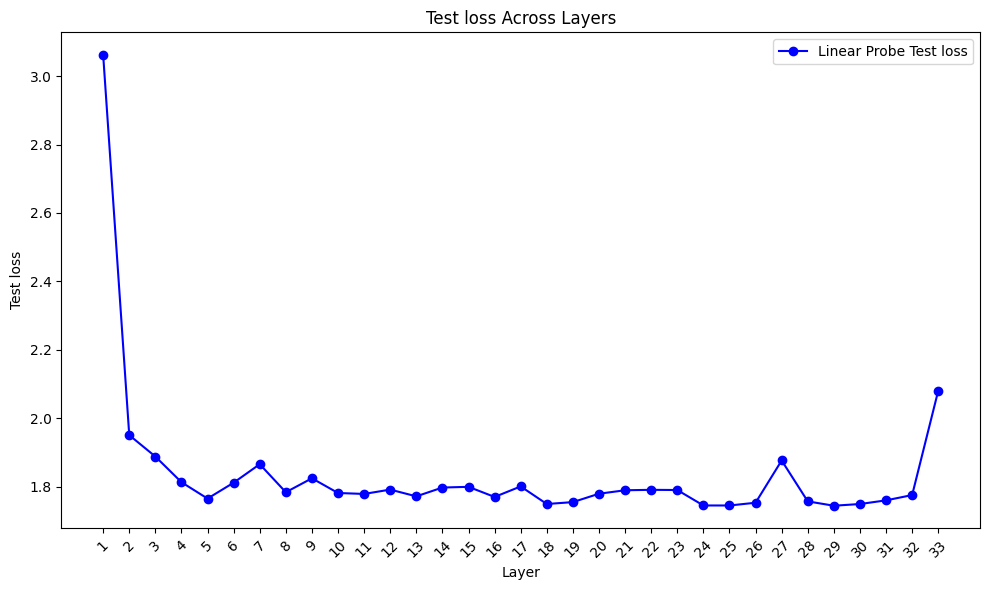

In [456]:
# Plot the best test losses across layers.
# Number of layers
def visualize_1d_losses(tbg_test_losses, metric_name="loss"):
    num_layers = len(tbg_test_losses)  # Assuming the same number of layers for both
    
    layers = np.arange(1, num_layers + 1)
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(layers, tbg_test_losses, label=f"Linear Probe Test {metric_name}", marker='o', linestyle='-', color='blue')
    
    # Adding labels and title
    plt.xlabel('Layer')
    plt.ylabel(f'Test {metric_name}')
    plt.title(f'Test {metric_name} Across Layers')
    
    # Adding legend
    plt.legend()
    
    # Tilting x-axis labels for clarity
    plt.xticks(layers, rotation=45)
    
    # Show plot
    plt.tight_layout()
    plt.show()

visualize_1d_losses(tbg_test_losses)

### Test models (on one particular layer) on other layers.

Previously, we only trained and evaluated models within each layer's embedding splits ([200, 4096]). Now we would like to see the linear probe's extrapolation ability to the same token on other layers.

In [ ]:
# Initialize a matrix to store the cross-dataset losses
tbg_cross_dataset_losses = torch.zeros(len(tbg_best_models), len(tbg_train_dataloaders))

for i, model in enumerate(tbg_best_models):
    # Evaluate on training datasets
    for j, valid_loader in enumerate(tbg_valid_dataloaders):
        loss = evaluate_on_test(model, valid_loader, device)
        tbg_cross_dataset_losses[i, j] = loss

# Compare the cross-dataset losses with best_losses for each model
for i, (best_loss, model) in enumerate(zip(tbg_best_losses, tbg_best_models)):
    print(f"Model {i+1}:")
    print(f"  Best Loss (on its own valid set): {best_loss:.4f}")
    for j in range(len(tbg_valid_dataloaders)):
        print(f"  Loss on Validation Dataset {j+1}: {tbg_cross_dataset_losses[i, j]:.4f}")

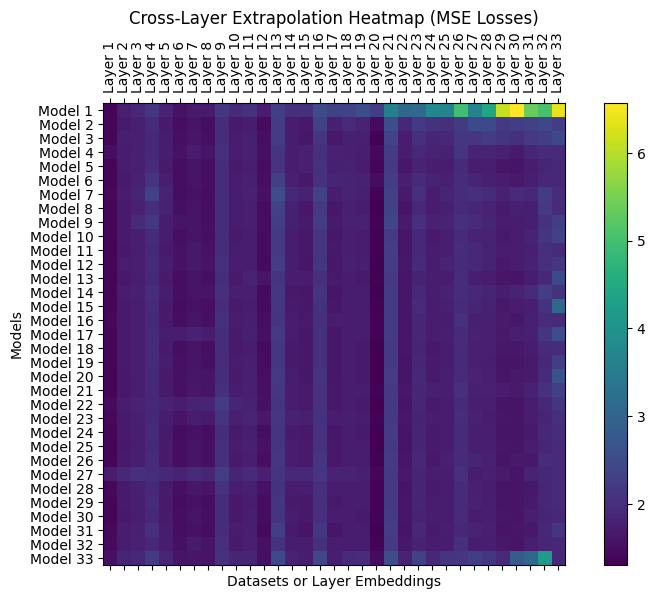

In [389]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_2d_losses(tbg_cross_dataset_losses):
    tbg_cross_dataset_losses_np = tbg_cross_dataset_losses.numpy()
    
    num_models = tbg_cross_dataset_losses_np.shape[0]
    num_datasets = tbg_cross_dataset_losses_np.shape[1]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    cax = ax.matshow(tbg_cross_dataset_losses_np, cmap='viridis')
    
    # Add color bar to interpret values
    fig.colorbar(cax)
    
    # Set axis labels
    ax.set_xlabel('Datasets or Layer Embeddings')
    ax.set_ylabel('Models')
    ax.set_title('Cross-Layer Extrapolation Heatmap (MSE Losses)')
    
    # Label each axis with dataset/model numbers
    ax.set_xticks(np.arange(num_datasets))
    ax.set_yticks(np.arange(num_models))
    
    ax.set_xticklabels([f'Layer {i+1}' for i in range(0, num_datasets)], rotation=90)
    ax.set_yticklabels([f'Model {i+1}' for i in range(0, num_models)])
    
    plt.show()

visualize_2d_losses(tbg_cross_dataset_losses)

The first-layer model made comparably more error in using later layer embeddings for predicting SE.

In [264]:
# Last layer
tok_bef_gen_layered_datasets[-1].min(), tok_bef_gen_layered_datasets[-1].max(), tok_bef_gen_layered_datasets[-1].var()

(tensor(-149.5000), tensor(107.1875), tensor(8.7053))

In [265]:
# Layers except last layer
tok_bef_gen_layered_datasets[:-1].min(), tok_bef_gen_layered_datasets[:-1].max(), tok_bef_gen_layered_datasets[:-1].var()

(tensor(-50.0625), tensor(76.6875), tensor(1.4603))

## Explore Second Last Generated Token by Model


In [266]:
sec_last_tok_dataset = torch.stack([record['most_likely_answer']['emb_tok_before_eos'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
print(sec_last_tok_dataset.shape)

torch.Size([2000, 33, 4544])


In [300]:
sec_last_tok_dataset.transpose(0, 1).shape

torch.Size([33, 2000, 4544])

In [301]:
slt_layered_datasets = sec_last_tok_dataset.transpose(0, 1)
print(slt_layered_datasets.shape, slt_layered_datasets.dtype)

torch.Size([33, 2000, 4544]) torch.float32


In [311]:
# We may want to drop the first layer due to its homogeneity in values.
# print(slt_layered_datasets[0], slt_layered_datasets[0].shape)
slt_layered_datasets = slt_layered_datasets[1:]

tensor([[-0.0069, -0.0206, -0.0239,  ...,  0.0623,  0.0408,  0.0635],
        [-0.0069, -0.0206, -0.0239,  ...,  0.0623,  0.0408,  0.0635],
        [-0.0069, -0.0206, -0.0239,  ...,  0.0623,  0.0408,  0.0635],
        ...,
        [-0.0069, -0.0206, -0.0239,  ...,  0.0623,  0.0408,  0.0635],
        [-0.0069, -0.0206, -0.0239,  ...,  0.0623,  0.0408,  0.0635],
        [-0.0069, -0.0206, -0.0239,  ...,  0.0623,  0.0408,  0.0635]]) torch.Size([2000, 4544])


In [302]:
# Inherit from previous section
# Make batched inputs and dataloaders (one for each layer)
total_size = 2000
batch_size = 32

slt_train_dataloaders, slt_valid_dataloaders, slt_pooled_test_dataloader = create_dataloaders(slt_layered_datasets, semantic_entropy, total_size, batch_size)

In [ ]:
# Training Loops
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [2048, 1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 100

slt_best_models = []
slt_best_losses = []
for i, (train_loader, valid_loader) in enumerate(zip(slt_train_dataloaders, slt_valid_dataloaders)):
    model = MLP(in_dim, hid_dims, out_dim, dropout)
    print(f"Training on Dataset {i+1}/{len(slt_train_dataloaders)}")
    best_model, best_loss, _ = train_and_evaluate(model, train_loader, valid_loader, device, epochs=epochs)
    slt_best_models.append(best_model)
    slt_best_losses.append(best_loss)

# Test best models trained separately on each layer on a pooled test set
slt_test_losses = []
for i, model in enumerate(slt_best_models):
    test_loss = evaluate_on_test(model, slt_pooled_test_dataloader, device)
    print(f"Model {i+1} Test Loss: {test_loss:.4f}")
    slt_test_losses.append(test_loss)

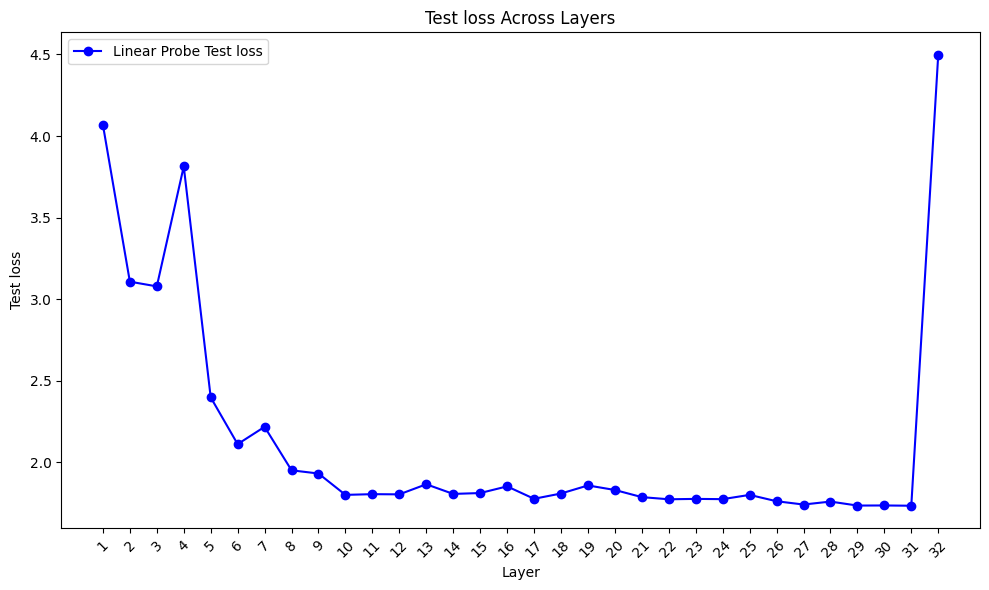

In [461]:
# Plot the best test losses across layers.
visualize_1d_losses(slt_test_losses[1:])

In [ ]:
# This time we evaluate other layers' training sets (since they should also be OOD data to specific layer models)
slt_cross_dataset_losses = torch.zeros(len(slt_best_models), len(slt_train_dataloaders))

for i, model in enumerate(slt_best_models):
    for j, valid_loader in enumerate(slt_valid_dataloaders):
        loss = evaluate_on_test(model, valid_loader, device)
        slt_cross_dataset_losses[i, j] = loss

for i, (best_loss, model) in enumerate(zip(slt_best_losses, slt_best_models)):
    print(f"Model {i+1}:")
    print(f"  Best Loss (on its own validation set): {best_loss:.4f}")
    for k in range(len(slt_valid_dataloaders)):
        print(f"  Loss on Validation Dataset {k+1}: {slt_cross_dataset_losses[i, k]:.4f}")

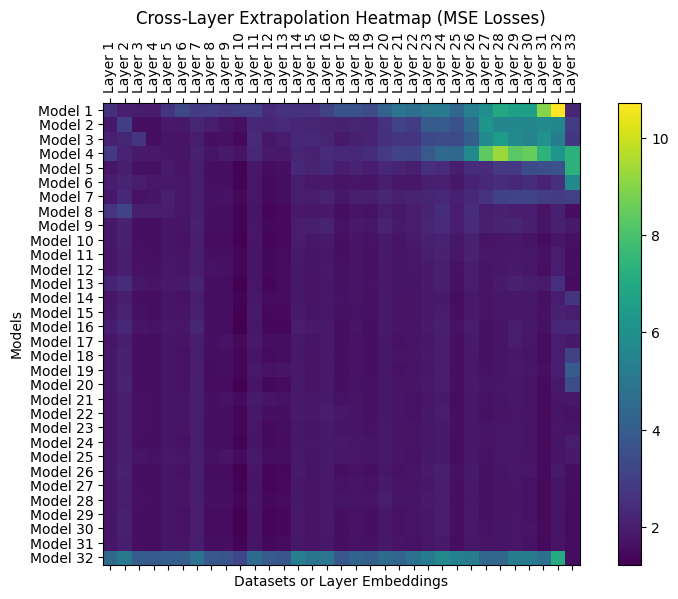

In [396]:
visualize_2d_losses(slt_cross_dataset_losses[1:, :])

It seems that **with more number of samples and more stablized model training steps, the cross-layer model performance gaps become smoothened and it is harder to observe consistent trends**. The cross-layer losses (MSE) are also notably lower for the lower triangular loss matrix. The comparison was made with the previous notebook (2024-o3-14).

As before, we see how models can extrapolate across token positions (even though we have only saved information on two positions).

### Test Models across Token Positions


(SLT: second last generated token before stopping token; TBG: last input token before first generated token)

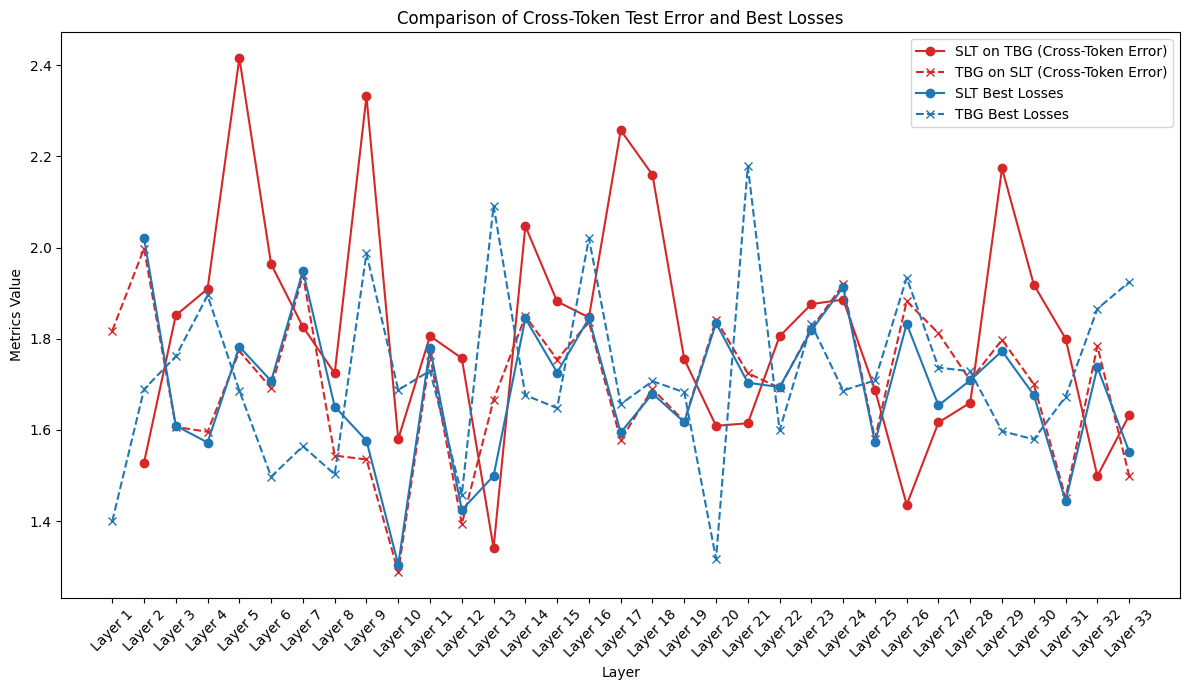

In [340]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming num_layers, cross_token_errors, slt_best_losses, and tbg_best_losses are defined

fig, ax = plt.subplots(figsize=(12, 7))

# Set the colors for each dataset
color_cross_token = 'tab:red'
color_best_losses = 'tab:blue'

# Plot Cross-Token Test Errors
ax.plot(np.arange(2, num_layers + 1), cross_token_errors[1:, 0], marker='o', color=color_cross_token, linestyle='-', label='SLT on TBG (Cross-Token Error)')
ax.plot(np.arange(1, num_layers + 1), cross_token_errors[:, 1], marker='x', color=color_cross_token, linestyle='--', label='TBG on SLT (Cross-Token Error)')

# Plot Best Losses
ax.plot(np.arange(2, num_layers + 1), slt_best_losses[1:], marker='o', color=color_best_losses, linestyle='-', label='SLT Best Losses')
ax.plot(np.arange(1, num_layers + 1), tbg_best_losses, marker='x', color=color_best_losses, linestyle='--', label='TBG Best Losses')

# Labeling Axes
ax.set_xlabel('Layer')
ax.set_ylabel('Metrics Value')
ax.tick_params(axis='y')

# Legend
ax.legend(loc='best')

# Title and X-ticks
plt.title('Comparison of Cross-Token Test Error and Best Losses')
plt.xticks(np.arange(1, num_layers + 1), [f'Layer {i}' for i in range(1, num_layers + 1)], rotation=45)  # Tilting x-axis labels for clarity

fig.tight_layout()
plt.show()

It is notable that two loss lines (SLT best losses and losses from TBG on SLT) overlap significantly, which might mean that **models trained on the TBG token may work for SLT token equally well across layers.**

## (In-Progress) Predict Accuracy from Token Embeddings

It would be interesting to see how linear probes perform at predicting accuracy obtained from using semantic entropy at selecting the most probable answer (true or false), as indicated in the `compute_uncertainty_measures.py` (_# For the semantic uncertainties, we can also change the prediction, by first selecting the semantic cluster with the highest probability, and then selecting the generation with the highest probability within that cluster._)

In [425]:
accuracies = torch.tensor([record['most_likely_answer']['accuracy'] for record in generations.values()])
print(accuracies.shape, accuracies[:10])  # "Accuracies" are binary. Classification task.

torch.Size([2000]) tensor([1., 1., 1., 1., 0., 0., 0., 0., 0., 0.])


In [441]:
# Create data loaders from tbg embeddings
acc_tbg_train_dl, acc_tbg_valid_dl, acc_tbg_pl_test_dl = create_dataloaders(tok_bef_gen_layered_datasets, accuracies, total_size, batch_size)

In [451]:
# Adapt model for binary classification.
class Classifier(MLP):
    def __init__(self, in_dim, hid_dims, dropout):
        super().__init__(in_dim, hid_dims, out_dim=1, dropout=dropout)

    def forward(self, x):
        x = super().forward(x)
        x = torch.sigmoid(x) 
        return x

In [453]:
# Training Loops (NOTE: Validation losses rise while training losses decrease.)
in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [2048, 1024, 512]
dropout = 0.5  # Dropout rate

epochs = 100

acc_tbg_best_models = []
acc_tbg_best_accuracies = []
for i, (train_loader, valid_loader) in enumerate(zip(acc_tbg_train_dl, acc_tbg_valid_dl)):
    model = Classifier(in_dim, hid_dims, dropout)
    # model = Classifier(in_dim)
    print(f"Training on Dataset {i+1}/{len(acc_tbg_train_dl)}")
    best_model, _, best_accuracy = train_and_evaluate(model, train_loader, valid_loader, device, nn.BCELoss(), epochs, binary_cls=True)
    acc_tbg_best_models.append(best_model)
    acc_tbg_best_accuracies.append(best_accuracy)

# Test best models trained separately on each layer on a pooled test set
acc_tbg_test_accuracies = []
acc_tbg_test_losses = []
for i, model in enumerate(acc_tbg_best_models):
    test_loss, test_accuracy = evaluate_on_test(model, acc_tbg_pl_test_dl, device, nn.BCELoss(), True)
    acc_tbg_test_accuracies.append(test_accuracy)
    acc_tbg_test_losses.append(test_loss)

Test Loss: 1.2582, Test Accuracy: 0.5511
Test Loss: 0.6497, Test Accuracy: 0.6324
Test Loss: 0.6186, Test Accuracy: 0.6561
Test Loss: 0.6204, Test Accuracy: 0.6414
Test Loss: 0.6360, Test Accuracy: 0.6353
Test Loss: 0.6193, Test Accuracy: 0.6556
Test Loss: 0.6345, Test Accuracy: 0.6427
Test Loss: 0.6062, Test Accuracy: 0.6740
Test Loss: 0.5921, Test Accuracy: 0.6770
Test Loss: 0.6358, Test Accuracy: 0.6504
Test Loss: 0.6032, Test Accuracy: 0.6740
Test Loss: 0.5812, Test Accuracy: 0.6911
Test Loss: 0.6149, Test Accuracy: 0.6583
Test Loss: 0.5752, Test Accuracy: 0.7045
Test Loss: 0.5473, Test Accuracy: 0.7245
Test Loss: 0.5776, Test Accuracy: 0.6686
Test Loss: 0.5703, Test Accuracy: 0.6911
Test Loss: 0.6015, Test Accuracy: 0.6583
Test Loss: 0.5679, Test Accuracy: 0.6862
Test Loss: 0.5371, Test Accuracy: 0.7431
Test Loss: 0.5833, Test Accuracy: 0.7153
Test Loss: 0.5857, Test Accuracy: 0.7193
Test Loss: 0.6000, Test Accuracy: 0.6976
Test Loss: 0.5722, Test Accuracy: 0.7214
Test Loss: 0.584

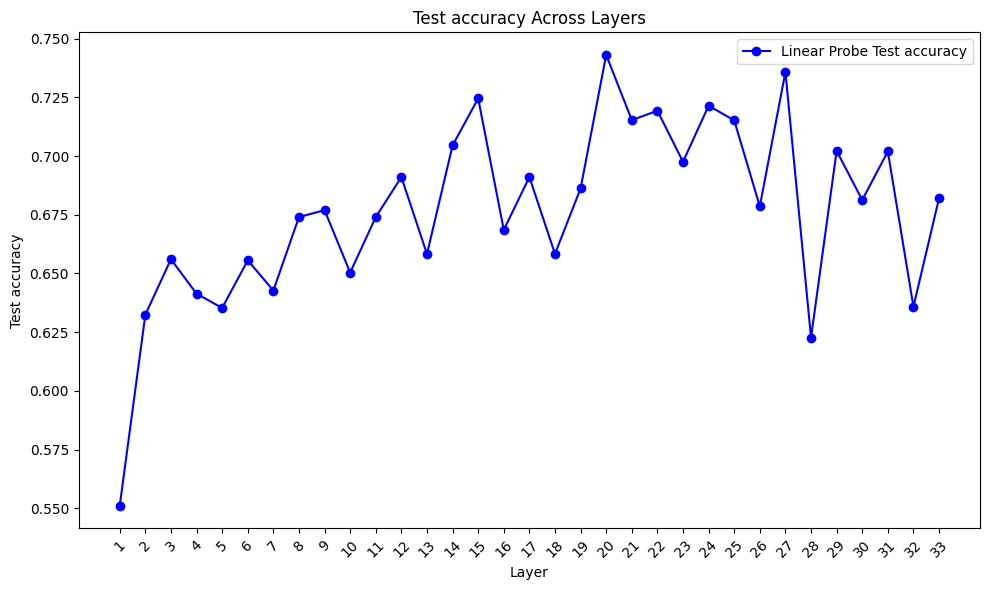

In [457]:
visualize_1d_losses(acc_tbg_test_accuracies, metric_name="accuracy")

It is somewhat consistent with our observation from predicting semantic entropy that **using later layer embeddings for training MLPs will in general yield more generalizable linear probes on test set (namely, across all layer embeddings)**.